In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase, HandlerLineCollection
from matplotlib.collections import LineCollection
import seaborn as sns
import math
import numpy as np

In [2]:
# Loading processed data
processed_df = pd.read_csv(r"C:\Users\loisr\Automated-IT-Support-Ticket-Intelligence\data\processed\df_integrated.csv")
processed_summary_df = pd.read_csv(r"C:\Users\loisr\Automated-IT-Support-Ticket-Intelligence\data\processed\summary_csv")

# Or use nbimporter to import notebooks directly
# !pip install nbimporter
# import nbimporter
# from src import 01_data_integration as data_integ

# Access variables:
# df = data_integ.df
# summary_df = data_integ.summary_df 

In [3]:
# Threshold for categorical-like columns
max_unique_for_cat = 10  # adjust if needed

categorical_cols = []
continuous_cols = []

for col in processed_df.columns:
    n_unique = processed_df[col].nunique()
    if n_unique <= max_unique_for_cat:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)

print("Categorical-like columns:", categorical_cols)
print("Continuous-like columns:", continuous_cols)

Categorical-like columns: ['type', 'queue', 'priority', 'language']
Continuous-like columns: ['subject', 'body', 'answer', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


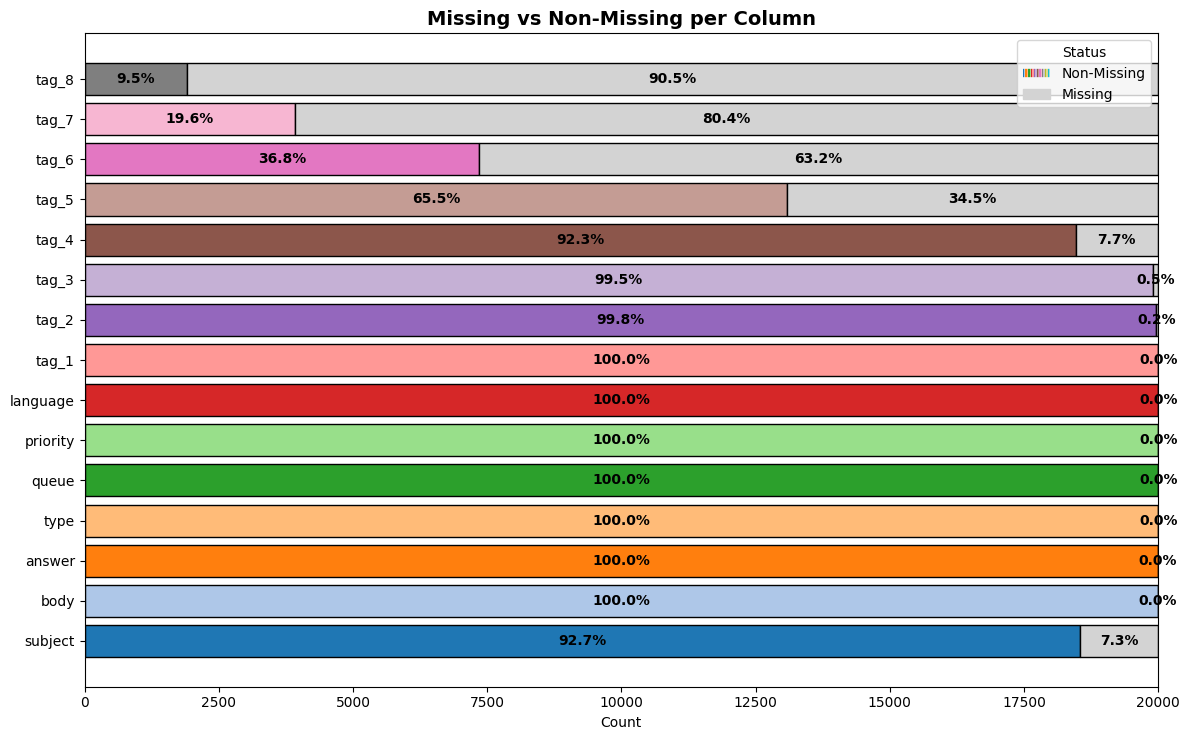

In [100]:
# missing_df['% Missing'].plot(kind='bar', figsize=(12,4))
# plt.title("Percentage of 'missing' per column")
# plt.ylabel("% Missing")
# plt.show()


# Count "missing" entries for each column
missing_summary = {col: (processed_df[col] == "missing").sum() for col in processed_df.columns}
missing_df = pd.DataFrame.from_dict(missing_summary, orient='index', columns=['Missing Count'])
missing_df['Non-Missing Count'] = len(processed_df) - missing_df['Missing Count']
missing_df['% Missing'] = missing_df['Missing Count'] / len(processed_df)
missing_df.sort_values('% Missing', ascending=False)


colors = plt.cm.tab20.colors 
n_cols = len(plot_df)

# Prepare a color list for each non-missing bar
non_missing_colors = [colors[i % len(colors)] for i in range(n_cols)]
missing_color = 'lightgrey'  # keep missing grey

# ---------------------------
# Create a rainbow patch
# ---------------------------
# Make a small gradient image for the legend
gradient = np.linspace(0, 1, 256).reshape(1, -1)  # 1x256 array
cmap = plt.cm.tab20  # same colormap as your bars

class HandlerColormap(HandlerBase):
    def __init__(self, cmap, **kw):
        self.cmap = cmap
        super().__init__(**kw)
    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):
        import matplotlib.patches as patches
        # rectangle filled with colormap gradient
        rect = patches.Rectangle([x0, y0], width, height, transform=trans,
                                 color='none')
        rect.set_facecolor(self.cmap(0.5))  # center color as approximation
        return [rect]
        

class HandlerColorLineCollection(HandlerLineCollection):
    def create_artists(self, legend, artist, xdescent, ydescent,
                       width, height, fontsize, trans):
        import numpy as np
        from matplotlib.collections import LineCollection

        x = np.linspace(0, width, self.get_numpoints(legend)+1)
        y = np.zeros(self.get_numpoints(legend)+1) + height/2. - ydescent
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(segments, cmap=artist.cmap, transform=trans)
        lc.set_array(x)
        lc.set_linewidth(artist.get_linewidth())

        return [lc]
        

# Create legend handles
rainbow_patch = LineCollection([[(0,0),(1,0)]], cmap=cmap, linewidth=6)
rainbow_patch.set_array(np.linspace(0,1,10))
missing_patch = mpatches.Patch(color='lightgrey', label='Missing')


fig, ax = plt.subplots(figsize=(12, max(6, n_cols*0.5)))

# Plot each bar individually so we can assign unique colors to non-missing
for i, col in enumerate(plot_df.index):
    counts = plot_df.loc[col]
    ax.barh(y=i, width=counts['Non-Missing Count'], color=non_missing_colors[i], edgecolor='black', label='Non-Missing' if i==0 else "")
    ax.barh(y=i, width=counts['Missing Count'], left=counts['Non-Missing Count'], color=missing_color, edgecolor='black', label='Missing' if i==0 else "")

    # Annotate percentages
    total = counts.sum()
    ax.text(counts['Non-Missing Count']/2, i, f'{counts["Non-Missing Count"]/total*100:.1f}%', 
            ha='center', va='center', color='black', fontweight='bold')
    ax.text(counts['Non-Missing Count'] + counts['Missing Count']/2, i, f'{counts["Missing Count"]/total*100:.1f}%', 
            ha='center', va='center', color='black', fontweight='bold')

ax.set_yticks(range(n_cols))
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Count")
ax.set_title("Missing vs Non-Missing per Column", fontsize=14, fontweight='bold')

# Show only one legend per category
ax.legend(handles=[rainbow_patch, missing_patch],
          labels=['Non-Missing', 'Missing'],
          handler_map={rainbow_patch: HandlerColorLineCollection(numpoints=100)},
          title='Status',
          loc='upper right')
plt.tight_layout()
plt.show()

In [9]:
tag_cols = [f"tag_{i}" for i in range(1,9)]
# print(tag_cols)

tag_cols_df = processed_df[tag_cols].fillna("missing")
# print(tag_cols_df)

# Converting each tag column into its own data frame
tag_dfs = {col: tag_cols_df[[col]].copy() for col in tag_cols}

C:\Users\loisr\AppData\Local\Temp\ipykernel_21308\2661932405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


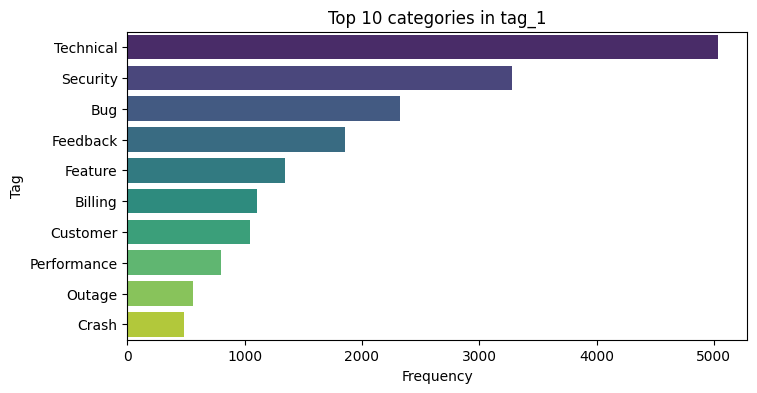

C:\Users\loisr\AppData\Local\Temp\ipykernel_21308\2661932405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


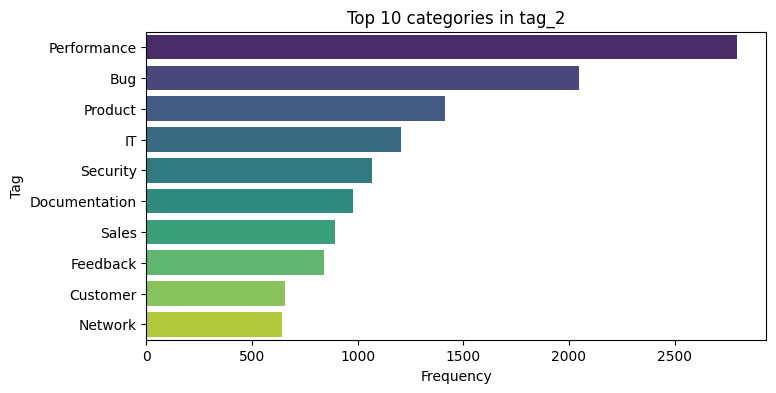

C:\Users\loisr\AppData\Local\Temp\ipykernel_21308\2661932405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


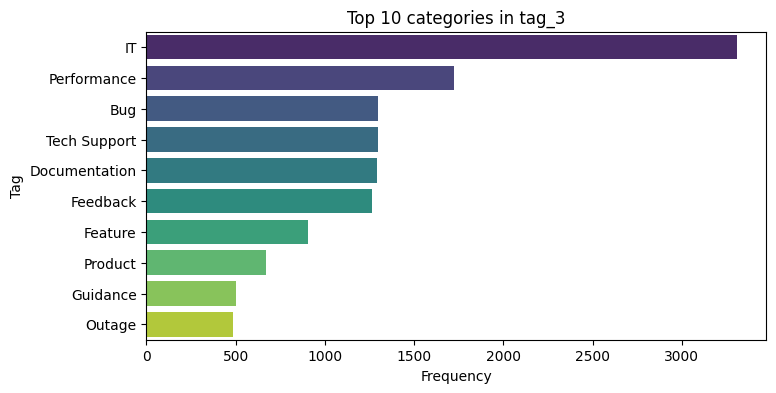

C:\Users\loisr\AppData\Local\Temp\ipykernel_21308\2661932405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


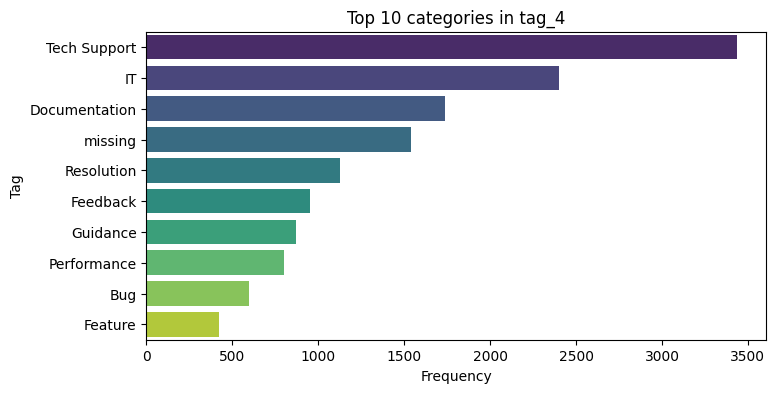

C:\Users\loisr\AppData\Local\Temp\ipykernel_21308\2661932405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


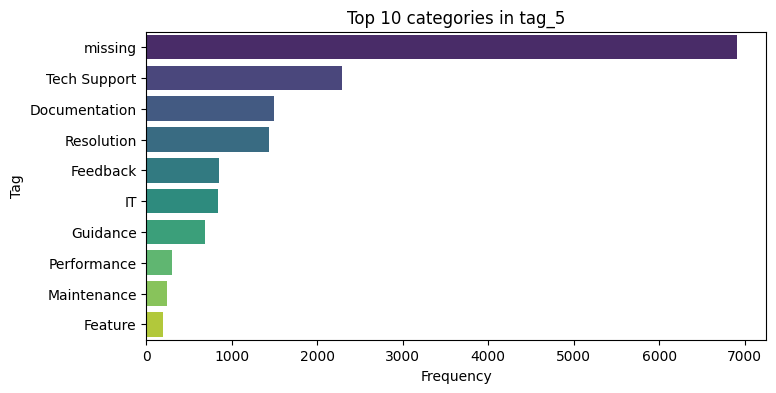

C:\Users\loisr\AppData\Local\Temp\ipykernel_21308\2661932405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


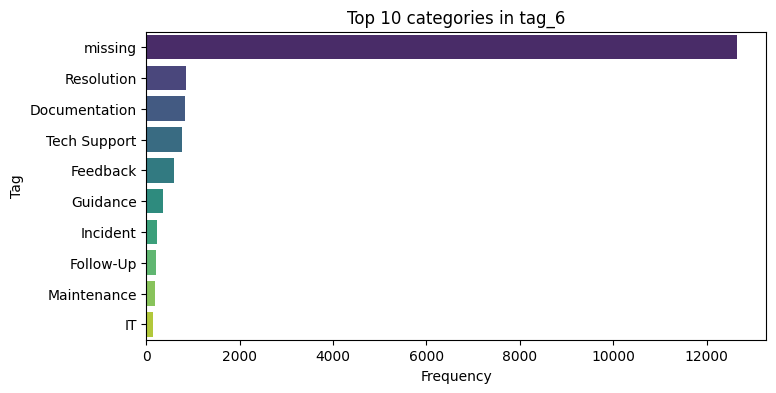

C:\Users\loisr\AppData\Local\Temp\ipykernel_21308\2661932405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


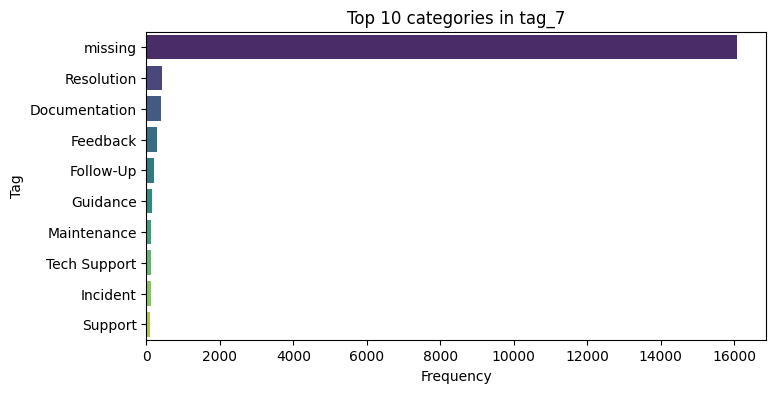

C:\Users\loisr\AppData\Local\Temp\ipykernel_21308\2661932405.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")


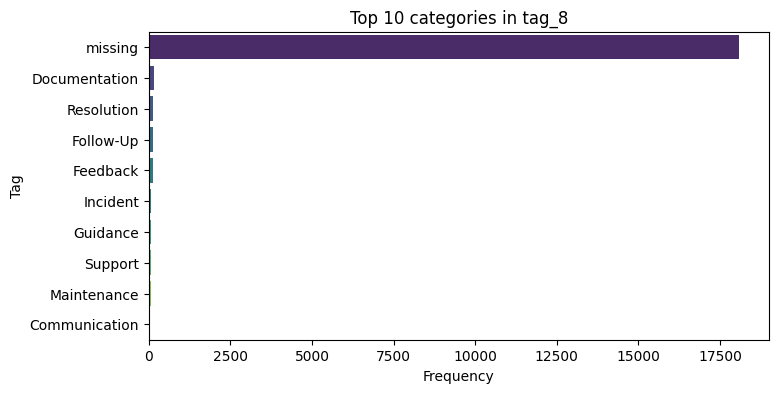

In [10]:
# Visualizing the frequency of each categroy per tag column
for col, df_tag in tag_dfs.items():
    # Count occurrences of each unique value
    value_counts = df_tag[col].value_counts()
    
    # Optional: only take top N tags for clarity
    top_n = 10
    top_counts = value_counts.head(top_n)
    
    # Create horizontal bar plot
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_counts.values, y=top_counts.index, palette="viridis")
    plt.title(f"Top {top_n} categories in {col}")
    plt.xlabel("Frequency")
    plt.ylabel("Tag")
    plt.show()

In [11]:
 # NLP objectives:

# Group tickets by priority
# Ensure priority column exists and is standardized
processed_df['priority'] = processed_df['priority'].str.lower().fillna('unknown')


high_priority = processed_df[processed_df['priority'] == 'high']
medium_priority = processed_df[processed_df['priority'] == 'medium']
low_priority = processed_df[processed_df['priority'] == 'low']

In [ ]:
# from collections import Counter
# import re

# def get_word_freq(df, text_cols=['subject','body']):
#     all_text = ' '.join(df[col].astype(str).str.lower().str.cat(sep=' ') for col in text_cols)
#     # Remove punctuation and split
#     words = re.findall(r'\b\w+\b', all_text)
#     # Count words
#     return Counter(words)

# high_words = get_word_freq(high_priority)
# medium_words = get_word_freq(medium_priority)
# low_words = get_word_freq(low_priority)

# # Example: top 20 words for high priority
# print(high_words.most_common(20))
# print(medium_words.most_common(20))
# print(low_words.most_common(20))

In [15]:
# How do different types of requests and queues relate to priority, and what does that imply about resource allocation?
# Goal: Identify patterns in high-priority requests

# Which IT support tags correspond to critical tickets, and can they be clustered to understand systemic issues?
# Goal: Highlight recurring problems or bottlenecks

# Are there areas where tickets are mis-prioritized relative to business impact
# Goal: Suggest rules for better prioritization and risk management

def get_freq_by_priority(df, col):
    freq = df.groupby(['priority', col]).size().reset_index(name='count')
    # Convert to percentage per priority
    freq['percent'] = freq.groupby('priority')['count'].transform(lambda x: x / x.sum() * 100)
    return freq

type_freq = get_freq_by_priority(high_priority, 'type')
queue_freq = get_freq_by_priority(high_priority, 'queue')

In [63]:
def plot_freq_multiple(freq_list, col_list, title_list):
    """
    freq_list: list of frequency dataframes
    col_list: list of column names for x-axis
    title_list: list of titles for each subplot
    """
    n = len(freq_list)
    fig, axs = plt.subplots(n, 1, figsize=(10, 5*n))  # n rows, 1 column
    if n == 1:
        axs = [axs]  # make it iterable if only one subplot


    for i in range(n):
        ax = axs[i]

        # ---------------------------
        # Plot bars (single color)
        # ---------------------------
        sns.barplot(data=freq_list[i],
                    x=col_list[i],
                    y='percent',
                   hue='priority',
                    dodge=False,
                    ax=ax,
                   edgecolor="black",
                   palette=["royalblue"])

        # ---------------------------
        # Titles and labels
        # ---------------------------
        ax.set_title(title_list[i], fontsize=14, fontweight='bold')
        ax.set_ylabel('Percentage (%)', fontsize=12, color="black")
        ax.set_xlabel(col_list[i].capitalize(), fontsize=12, color="black")
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        ax.legend(title='Priority')

        # ---------------------------
        # Add value labels
        # ---------------------------
        for p in ax.patches:
            height = p.get_height()
            if height > 0:  # only label bars with non-zero height
                ax.annotate(f'{height:.1f}%', 
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

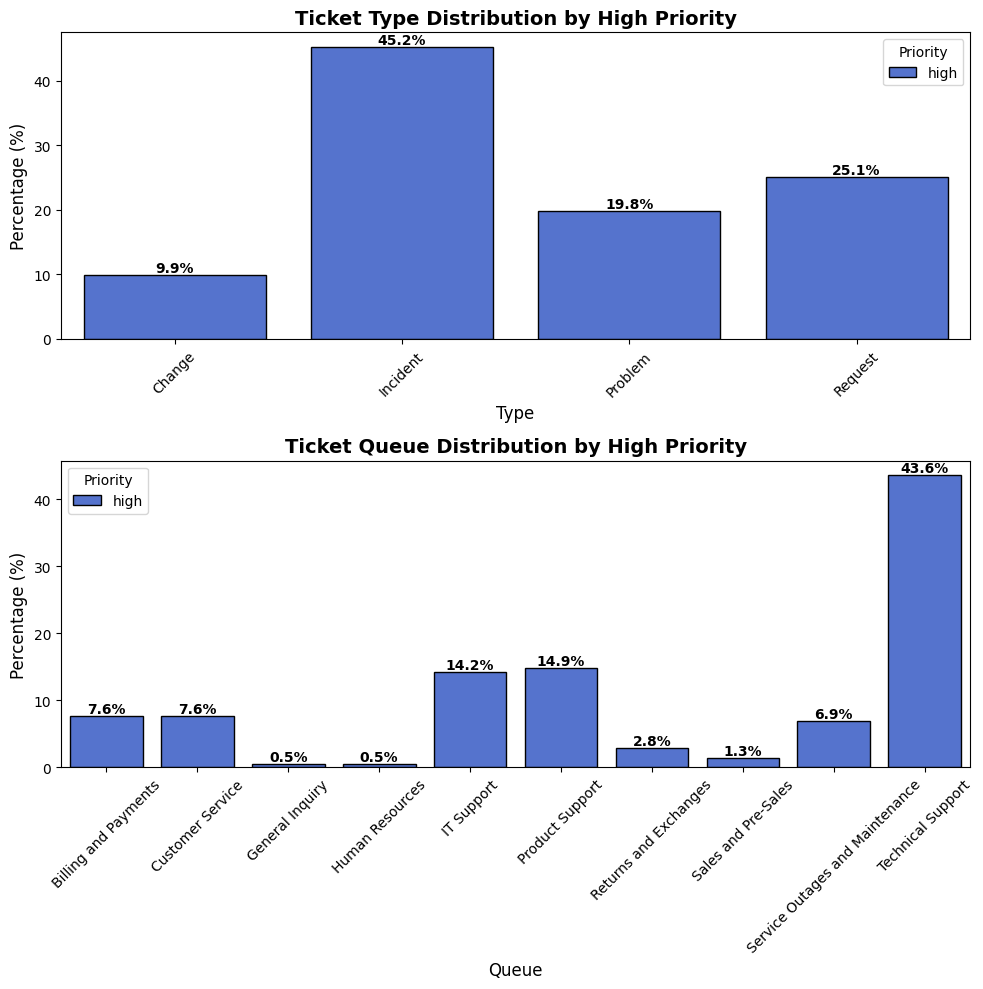

In [64]:
freq_list = [type_freq, queue_freq]
col_list = ['type', 'queue']
title_list = [
    'Ticket Type Distribution by High Priority',
    'Ticket Queue Distribution by High Priority'
]

plot_freq_multiple(freq_list, col_list, title_list)